# Decision Trees, Clustering, and Related ML Concepts — Demonstration Notebook

This notebook demonstrates the following concepts:

1. K-means and spherical clusters  
2. Internal nodes in decision trees  
3. CART as a supervised and greedy algorithm  
4. Building a decision tree using `DecisionTreeClassifier`  
5. Gini Index and binary splits  
6. Chance nodes in decision analysis  
7. Entropy as impurity / uncertainty  
8. End nodes in decision analysis  
9. Class imbalance and balancing before fitting  
10. Regression tree for house-price prediction

In [1]:
!pip -q install ipywidgets graphviz pydot imbalanced-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 19.4 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

from sklearn.datasets import make_blobs, make_classification, make_regression, load_iris
from sklearn.cluster import KMeans
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree, export_text
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, mean_squared_error, r2_score
from sklearn.inspection import DecisionBoundaryDisplay

from collections import Counter
import matplotlib.patches as patches

import ipywidgets as widgets
from ipywidgets import interact, IntSlider

plt.rcParams["figure.figsize"] = (8,5)
np.random.seed(42)

print("Libraries imported successfully.")

Libraries imported successfully.


## Concept 1 — K-means works best for hyper-spherical clusters

K-means performs well when clusters are:
- roughly circular / spherical
- well-separated
- of similar size

This is because K-means groups points based on the **nearest centroid**.

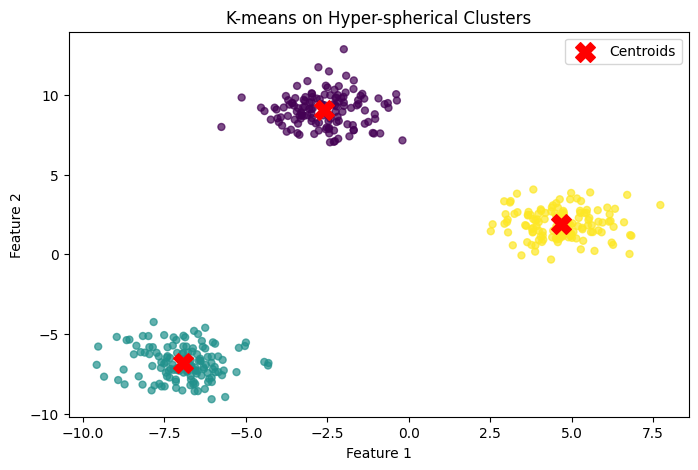

In [3]:
# Generate spherical clusters
X, y = make_blobs(n_samples=400, centers=3, cluster_std=1.0, random_state=42)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = kmeans.fit_predict(X)
centers = kmeans.cluster_centers_

plt.scatter(X[:,0], X[:,1], c=labels, s=25, alpha=0.7)
plt.scatter(centers[:,0], centers[:,1], c='red', s=200, marker='X', label='Centroids')
plt.title("K-means on Hyper-spherical Clusters")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

In [4]:
@interact(k=IntSlider(value=3, min=2, max=6, step=1, description='k'))
def show_kmeans(k=3):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    pred = model.fit_predict(X)
    c = model.cluster_centers_

    plt.figure(figsize=(7,5))
    plt.scatter(X[:,0], X[:,1], c=pred, s=25, alpha=0.7)
    plt.scatter(c[:,0], c[:,1], c='black', s=180, marker='X')
    plt.title(f"K-means with k = {k}")
    plt.show()

interactive(children=(IntSlider(value=3, description='k', max=6, min=2), Output()), _dom_classes=('widget-inte…

## Concept 2 — Internal node in a Decision Tree

In a Decision Tree:

- **Root node** → entire dataset  
- **Internal node** → a test on an attribute  
- **Branch** → outcome of the test  
- **Leaf node** → class label / final prediction

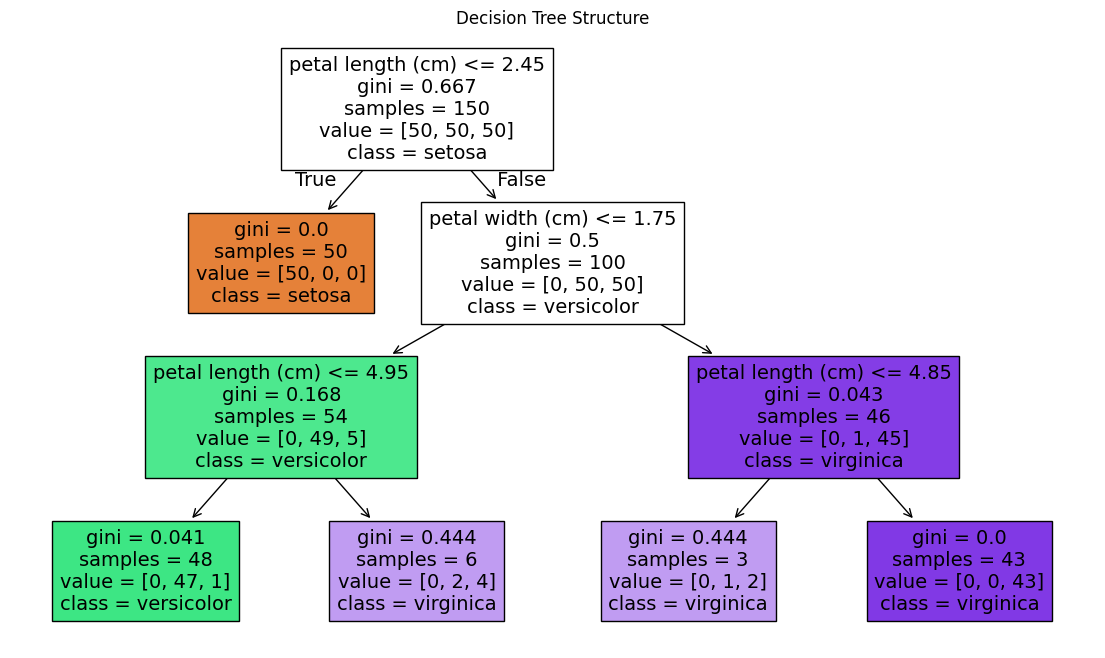

Text version of the tree:

|--- petal length (cm) <= 2.45
|   |--- class: 0
|--- petal length (cm) >  2.45
|   |--- petal width (cm) <= 1.75
|   |   |--- petal length (cm) <= 4.95
|   |   |   |--- class: 1
|   |   |--- petal length (cm) >  4.95
|   |   |   |--- class: 2
|   |--- petal width (cm) >  1.75
|   |   |--- petal length (cm) <= 4.85
|   |   |   |--- class: 2
|   |   |--- petal length (cm) >  4.85
|   |   |   |--- class: 2



In [5]:
iris = load_iris()
X_iris = iris.data
y_iris = iris.target

clf = DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X_iris, y_iris)

plt.figure(figsize=(14,8))
plot_tree(
    clf,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True
)
plt.title("Decision Tree Structure")
plt.show()

print("Text version of the tree:\n")
print(export_text(clf, feature_names=list(iris.feature_names)))

## Concept 3 — CART is supervised and greedy

CART stands for **Classification and Regression Trees**.

### Why supervised?
Because it learns from:
- input features `X`
- target labels `y`

### Why greedy?
At each step, it chooses the **best split immediately**.
It does not search all future tree possibilities globally.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X_iris, y_iris, test_size=0.3, random_state=42, stratify=y_iris
)

cart = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42)
cart.fit(X_train, y_train)

pred = cart.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))
print("\nClassification Report:\n")
print(classification_report(y_test, pred, target_names=iris.target_names))

Accuracy: 0.9777777777777777

Classification Report:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       1.00      0.93      0.97        15
   virginica       0.94      1.00      0.97        15

    accuracy                           0.98        45
   macro avg       0.98      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45



## Concept 4 — Building a Decision Tree using `DecisionTreeClassifier`

In Scikit-learn, the class used for a classification tree is:

```python
DecisionTreeClassifier

In [7]:

# **Cell 12 — DecisionTreeClassifier Demo**#

from sklearn.tree import DecisionTreeClassifier

demo_clf = DecisionTreeClassifier(random_state=42)
demo_clf.fit(X_train, y_train)

print("Model built successfully using DecisionTreeClassifier")
print("Predicted classes for first 5 test samples:", demo_clf.predict(X_test[:5]))

Model built successfully using DecisionTreeClassifier
Predicted classes for first 5 test samples: [2 1 2 2 2]


## Concept 5 — Gini Index does NOT enforce multiway splits

This statement is **False**.

### Important:
- Gini Index measures **impurity**
- It helps choose the **best split**
- It does **not** force the tree to have many branches

In CART, Gini is commonly used, and CART usually makes **binary splits**.

In [8]:
def gini_impurity(class_counts):
    total = sum(class_counts)
    probs = [c/total for c in class_counts if total > 0]
    return 1 - sum(p**2 for p in probs)

examples = {
    "Pure Node [10,0]": [10,0],
    "Mixed Node [5,5]": [5,5],
    "Moderately Mixed [8,2]": [8,2]
}

for name, counts in examples.items():
    print(f"{name}: Gini = {gini_impurity(counts):.3f}")

Pure Node [10,0]: Gini = 0.000
Mixed Node [5,5]: Gini = 0.500
Moderately Mixed [8,2]: Gini = 0.320


## Concept 6 & 8 — Chance Nodes and End Nodes in Decision Analysis

In decision analysis trees:

- **Square** → Decision node  
- **Circle** → Chance node  
- **Triangle** → End / Terminal node

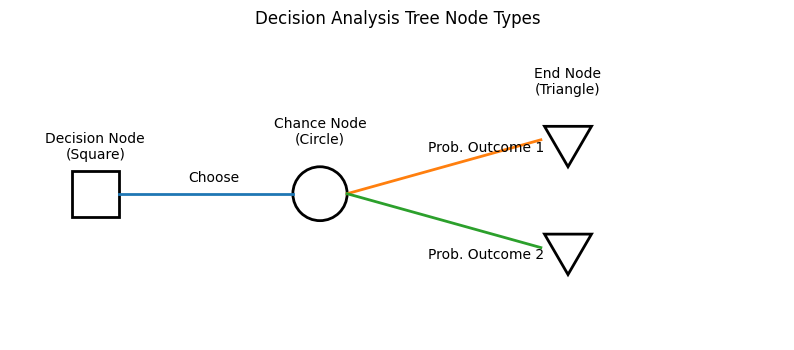

In [9]:
fig, ax = plt.subplots(figsize=(10,4))
ax.set_xlim(0, 10)
ax.set_ylim(0, 4)
ax.axis('off')

# Decision node (square)
square = patches.Rectangle((0.8, 1.6), 0.6, 0.6, fill=False, linewidth=2)
ax.add_patch(square)
ax.text(1.1, 2.35, "Decision Node\n(Square)", ha='center')

# Chance node (circle)
circle = patches.Circle((4, 1.9), 0.35, fill=False, linewidth=2)
ax.add_patch(circle)
ax.text(4, 2.55, "Chance Node\n(Circle)", ha='center')

# End nodes (triangles)
triangle1 = patches.RegularPolygon((7.2, 2.6), numVertices=3, radius=0.35, orientation=np.pi, fill=False, linewidth=2)
triangle2 = patches.RegularPolygon((7.2, 1.2), numVertices=3, radius=0.35, orientation=np.pi, fill=False, linewidth=2)
ax.add_patch(triangle1)
ax.add_patch(triangle2)
ax.text(7.2, 3.2, "End Node\n(Triangle)", ha='center')

# Connections
ax.plot([1.4, 3.65], [1.9, 1.9], linewidth=2)
ax.plot([4.35, 6.85], [1.9, 2.6], linewidth=2)
ax.plot([4.35, 6.85], [1.9, 1.2], linewidth=2)

ax.text(2.3, 2.05, "Choose", fontsize=10)
ax.text(5.4, 2.45, "Prob. Outcome 1", fontsize=10)
ax.text(5.4, 1.05, "Prob. Outcome 2", fontsize=10)

plt.title("Decision Analysis Tree Node Types")
plt.show()

## Concept 7 — Entropy is the measure of uncertainty / impurity

Entropy tells us how mixed or uncertain a node is.


### Interpretation:
- Entropy = 0 → pure node
- Higher entropy → more uncertainty / impurity

In [10]:
def entropy(class_counts):
    total = sum(class_counts)
    probs = [c/total for c in class_counts if c > 0]
    return -sum(p * math.log2(p) for p in probs)

examples = {
    "Pure Node [10,0]": [10,0],
    "Mixed Node [5,5]": [5,5],
    "Moderately Mixed [8,2]": [8,2]
}

for name, counts in examples.items():
    print(f"{name}: Entropy = {entropy(counts):.3f}")

Pure Node [10,0]: Entropy = -0.000
Mixed Node [5,5]: Entropy = 1.000
Moderately Mixed [8,2]: Entropy = 0.722


In [11]:
distributions = [[10,0], [9,1], [8,2], [7,3], [6,4], [5,5]]
rows = []
for d in distributions:
    rows.append({
        "Distribution": str(d),
        "Entropy": entropy(d),
        "Gini": gini_impurity(d)
    })

pd.DataFrame(rows)

,Distribution,Entropy,Gini
0,"[10, 0]",-0.000000,0.00
1,"[9, 1]",0.468996,0.18
2,"[8, 2]",0.721928,0.32
3,"[7, 3]",0.881291,0.42
4,"[6, 4]",0.970951,0.48
5,"[5, 5]",1.000000,0.50


## Concept 9 — Class imbalance can bias Decision Trees

If one class dominates the dataset, the tree may become biased toward that class.

### Correct solution:
**Balance the dataset prior to fitting**

In [12]:
X_imb, y_imb = make_classification(
    n_samples=1000,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    weights=[0.92, 0.08],  # Imbalanced
    class_sep=1.0,
    random_state=42
)

print("Original class distribution:", Counter(y_imb))

Original class distribution: Counter({np.int64(0): 915, np.int64(1): 85})


In [13]:
X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(
    X_imb, y_imb, test_size=0.3, random_state=42, stratify=y_imb
)

tree_imb = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_imb.fit(X_train_i, y_train_i)
pred_imb = tree_imb.predict(X_test_i)

print("Performance on imbalanced data:")
print(confusion_matrix(y_test_i, pred_imb))
print(classification_report(y_test_i, pred_imb))

Performance on imbalanced data:
[[275   0]
 [  5  20]]
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       275
           1       1.00      0.80      0.89        25

    accuracy                           0.98       300
   macro avg       0.99      0.90      0.94       300
weighted avg       0.98      0.98      0.98       300



In [14]:
minority_idx = np.where(y_train_i == 1)[0]
majority_idx = np.where(y_train_i == 0)[0]

n_majority = len(majority_idx)
oversampled_minority_idx = np.random.choice(minority_idx, size=n_majority, replace=True)

balanced_idx = np.concatenate([majority_idx, oversampled_minority_idx])

X_train_bal = X_train_i[balanced_idx]
y_train_bal = y_train_i[balanced_idx]

print("Balanced class distribution:", Counter(y_train_bal))

Balanced class distribution: Counter({np.int64(0): 640, np.int64(1): 640})


In [15]:
tree_bal = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_bal.fit(X_train_bal, y_train_bal)
pred_bal = tree_bal.predict(X_test_i)

print("Performance after balancing before fitting:")
print(confusion_matrix(y_test_i, pred_bal))
print(classification_report(y_test_i, pred_bal))

Performance after balancing before fitting:
[[271   4]
 [  5  20]]
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       275
           1       0.83      0.80      0.82        25

    accuracy                           0.97       300
   macro avg       0.91      0.89      0.90       300
weighted avg       0.97      0.97      0.97       300



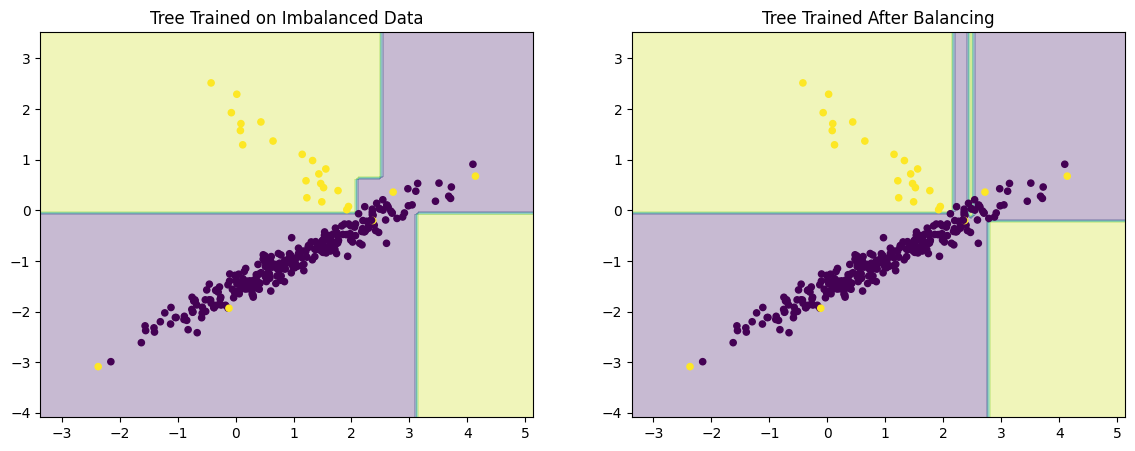

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

DecisionBoundaryDisplay.from_estimator(tree_imb, X_test_i, response_method="predict", alpha=0.3, ax=axes[0])
axes[0].scatter(X_test_i[:,0], X_test_i[:,1], c=y_test_i, s=20)
axes[0].set_title("Tree Trained on Imbalanced Data")

DecisionBoundaryDisplay.from_estimator(tree_bal, X_test_i, response_method="predict", alpha=0.3, ax=axes[1])
axes[1].scatter(X_test_i[:,0], X_test_i[:,1], c=y_test_i, s=20)
axes[1].set_title("Tree Trained After Balancing")

plt.show()

## Concept 10 — Predicting House Price requires a Regression Tree

If the target variable is a **continuous numeric value** like price, then we use:

```python
DecisionTreeRegressor

In [17]:

# Create House Price Style Data**

X_reg, y_reg = make_regression(
    n_samples=500,
    n_features=4,
    n_informative=4,
    noise=20,
    random_state=42
)

# Make target values look like house prices
y_reg = y_reg * 10000 + 5000000

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.25, random_state=42
)

In [23]:
reg_tree = DecisionTreeRegressor(max_depth=4, random_state=42)
reg_tree.fit(X_train_r, y_train_r)

pred_r = reg_tree.predict(X_test_r)

print("Regression Tree Results")
print("RMSE:", mean_squared_error(y_test_r, pred_r) ** 0.5)
print("R² Score:", r2_score(y_test_r, pred_r))

Regression Tree Results
RMSE: 319671.838479839
R² Score: 0.6875818415761707


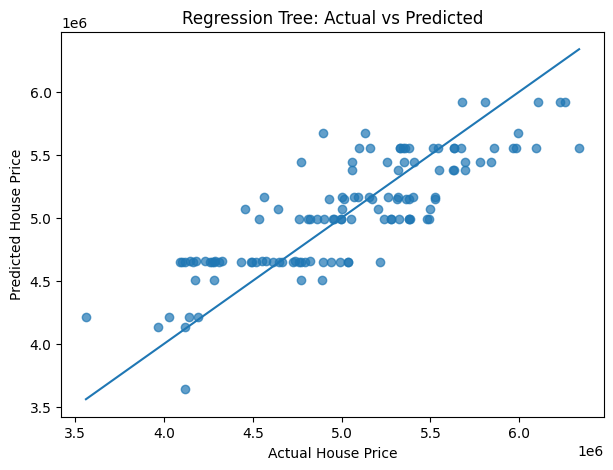

In [19]:
plt.figure(figsize=(7,5))
plt.scatter(y_test_r, pred_r, alpha=0.7)
plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Regression Tree: Actual vs Predicted")
plt.plot([y_test_r.min(), y_test_r.max()], [y_test_r.min(), y_test_r.max()])
plt.show()

In [20]:
@interact(depth=IntSlider(value=4, min=1, max=10, step=1, description='max_depth'))
def tune_regression_tree(depth=4):
    model = DecisionTreeRegressor(max_depth=depth, random_state=42)
    model.fit(X_train_r, y_train_r)
    pred = model.predict(X_test_r)

    rmse = mean_squared_error(y_test_r, pred) ** 0.5
    r2 = r2_score(y_test_r, pred)

    print(f"Depth: {depth}")
    print(f"RMSE: {rmse:,.2f}")
    print(f"R²: {r2:.4f}")

    plt.figure(figsize=(6,4))
    plt.scatter(y_test_r, pred, alpha=0.6)
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(f"Regression Tree Performance (depth={depth})")
    plt.show()

interactive(children=(IntSlider(value=4, description='max_depth', max=10, min=1), Output()), _dom_classes=('wi…

In [21]:
summary = pd.DataFrame({
    "Concept": [
        "K-means",
        "Internal node",
        "CART",
        "Classifier class",
        "Gini Index",
        "Chance node",
        "Entropy",
        "End node",
        "Class imbalance",
        "House price prediction"
    ],
    "Correct Idea": [
        "Works well for hyper-spherical clusters",
        "Represents a test on an attribute",
        "Supervised and greedy",
        "DecisionTreeClassifier",
        "Does not enforce multiway splits",
        "Circle",
        "Measure of uncertainty / impurity",
        "Triangle",
        "Balance before fitting",
        "Use Regression Tree"
    ]
})

summary

,Concept,Correct Idea
0,K-means,Works well for hyper-spherical clusters
1,Internal node,Represents a test on an attribute
2,CART,Supervised and greedy
3,Classifier class,DecisionTreeClassifier
4,Gini Index,Does not enforce multiway splits
5,Chance node,Circle
6,Entropy,Measure of uncertainty / impurity
7,End node,Triangle
8,Class imbalance,Balance before fitting
9,House price prediction,Use Regression Tree


# Conclusion

This notebook demonstrated:

- **Clustering using K-means**
- **Decision Tree components**
- **CART algorithm**
- **Gini Index and Entropy**
- **Decision analysis node types**
- **Effect of class imbalance**
- **Regression Tree for continuous prediction**

These concepts are foundational in **Machine Learning**, especially for:
- classification
- clustering
- decision making
- predictive analytics

## Viva / Exam Questions

1. Why does K-means work best for spherical clusters?
2. What is the role of an internal node in a decision tree?
3. Why is CART called a greedy algorithm?
4. What is the difference between Gini and Entropy?
5. Why is class imbalance dangerous in classification?
6. When do we use `DecisionTreeClassifier` vs `DecisionTreeRegressor`?